In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    classification_report, roc_auc_score,
    mean_absolute_error, r2_score, mean_squared_error,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    TimeSeriesSplit, learning_curve, cross_val_score, train_test_split
)
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv("nba_long_dataset2.csv")
df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
df = df.sort_values("GAME_DATE").reset_index(drop=True)

# Actual game result — not the rolling average
df["ACTUAL_PTS_DIFF"] = df["PTS_HOME"] - df["PTS_AWAY"]

# Pre-game features only — no leakage
reg_features = ["PTS_DIFF", "REB_DIFF", "AST_DIFF", "TOV_DIFF", "EFG_DIFF", "TRAVEL_DIST"]

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['GAME_DATE'].min()} to {df['GAME_DATE'].max()}")
print(f"Home win rate: {df['HOME_WIN'].mean():.4f}")
print(df["GAME_DATE"].dt.year.value_counts().sort_index())

Dataset shape: (9528, 28)
Date range: 2015-12-05 00:00:00 to 2025-04-13 00:00:00
Home win rate: 0.5690
GAME_DATE
2015     180
2016    1247
2017    1268
2018    1193
2019    1178
2020     450
2021     882
2022     418
2023    1077
2024    1024
2025     611
Name: count, dtype: int64


In [3]:
n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.90)

train = df.iloc[:train_end]
val   = df.iloc[train_end:val_end]
test  = df.iloc[val_end:]

X_train = train[reg_features]
X_val   = val[reg_features]
X_test  = test[reg_features]

y_clf_train = train["HOME_WIN"].astype(int)
y_clf_val   = val["HOME_WIN"].astype(int)
y_clf_test  = test["HOME_WIN"].astype(int)

y_reg_train = train["ACTUAL_PTS_DIFF"]
y_reg_val   = val["ACTUAL_PTS_DIFF"]
y_reg_test  = test["ACTUAL_PTS_DIFF"]

# Fit scaler on training data only - no leakage into val/test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 6669 | Val: 1906 | Test: 953


In [4]:
# Tune on validation only — test set never touched here
params = [
    {"max_depth": 3, "min_samples_leaf": 5},
    {"max_depth": 3, "min_samples_leaf": 10},
    {"max_depth": 4, "min_samples_leaf": 10},
    {"max_depth": 4, "min_samples_leaf": 20},
    {"max_depth": 5, "min_samples_leaf": 10},
    {"max_depth": 5, "min_samples_leaf": 20},
]

print("RF CLASSIFIER")
for p in params:
    rf = RandomForestClassifier(n_estimators=100, random_state=42, **p)
    rf.fit(X_train_scaled, y_clf_train)
    val_auc = round(roc_auc_score(y_clf_val, rf.predict_proba(X_val_scaled)[:, 1]), 4)
    trn_auc = round(roc_auc_score(y_clf_train, rf.predict_proba(X_train_scaled)[:, 1]), 4)
    print(f"depth={p['max_depth']}, min_leaf={p['min_samples_leaf']:2} | Train: {trn_auc} | Val: {val_auc} | Gap: {round(trn_auc-val_auc,4)}")

print("\nRF REGRESSOR")
for p in params:
    rf = RandomForestRegressor(n_estimators=100, random_state=42, **p)
    rf.fit(X_train_scaled, y_reg_train)
    val_r2 = round(r2_score(y_reg_val, rf.predict(X_val_scaled)), 4)
    trn_r2 = round(r2_score(y_reg_train, rf.predict(X_train_scaled)), 4)
    print(f"depth={p['max_depth']}, min_leaf={p['min_samples_leaf']:2} | Train: {trn_r2} | Val: {val_r2} | Gap: {round(trn_r2-val_r2,4)}")

RF CLASSIFIER
depth=3, min_leaf= 5 | Train: 0.6571 | Val: 0.6327 | Gap: 0.0244
depth=3, min_leaf=10 | Train: 0.6571 | Val: 0.6329 | Gap: 0.0242
depth=4, min_leaf=10 | Train: 0.6711 | Val: 0.6371 | Gap: 0.034
depth=4, min_leaf=20 | Train: 0.6707 | Val: 0.6376 | Gap: 0.0331
depth=5, min_leaf=10 | Train: 0.689 | Val: 0.6398 | Gap: 0.0492
depth=5, min_leaf=20 | Train: 0.6849 | Val: 0.6386 | Gap: 0.0463

RF REGRESSOR
depth=3, min_leaf= 5 | Train: 0.0941 | Val: 0.0719 | Gap: 0.0222
depth=3, min_leaf=10 | Train: 0.094 | Val: 0.0721 | Gap: 0.0219
depth=4, min_leaf=10 | Train: 0.1135 | Val: 0.0798 | Gap: 0.0337
depth=4, min_leaf=20 | Train: 0.112 | Val: 0.0801 | Gap: 0.0319
depth=5, min_leaf=10 | Train: 0.1351 | Val: 0.0825 | Gap: 0.0526
depth=5, min_leaf=20 | Train: 0.1309 | Val: 0.0827 | Gap: 0.0482


In [5]:
# Logistic Regression — baseline classifier, L2 regularization, converges in <100 iterations
lr = LogisticRegression(max_iter=100, random_state=42)
lr.fit(X_train_scaled, y_clf_train)
lr_val_pred  = lr.predict(X_val_scaled)
lr_val_proba = lr.predict_proba(X_val_scaled)[:, 1]
lr_tst_pred  = lr.predict(X_test_scaled)
lr_tst_proba = lr.predict_proba(X_test_scaled)[:, 1]

# Ridge Regression — baseline regressor, L2 penalty stabilizes correlated features
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_reg_train)
ridge_val_pred = ridge.predict(X_val_scaled)
ridge_tst_pred = ridge.predict(X_test_scaled)

# Random Forest Classifier — max_depth=3, min_samples_leaf=10 chosen from validation tuning
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=3, min_samples_leaf=10, random_state=42)
rf_clf.fit(X_train_scaled, y_clf_train)
rf_clf_val_pred  = rf_clf.predict(X_val_scaled)
rf_clf_val_proba = rf_clf.predict_proba(X_val_scaled)[:, 1]
rf_clf_tst_pred  = rf_clf.predict(X_test_scaled)
rf_clf_tst_proba = rf_clf.predict_proba(X_test_scaled)[:, 1]

# Random Forest Regressor — same regularization parameters
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=10, random_state=42)
rf_reg.fit(X_train_scaled, y_reg_train)
rf_reg_val_pred = rf_reg.predict(X_val_scaled)
rf_reg_tst_pred = rf_reg.predict(X_test_scaled)

print("All 4 models trained.")

All 4 models trained.


In [7]:
print("="*50)
print("LOGISTIC REGRESSION")
print("="*50)
print(f"Train AUC : {round(roc_auc_score(y_clf_train, lr.predict_proba(X_train_scaled)[:,1]),4)}")
print(f"Val AUC   : {round(roc_auc_score(y_clf_val, lr_val_proba),4)}")
print(f"Test AUC  : {round(roc_auc_score(y_clf_test, lr_tst_proba),4)}")
print(f"Accuracy  : {round(lr.score(X_test_scaled, y_clf_test),4)}")
print(classification_report(y_clf_test, lr_tst_pred, target_names=["Home Loss","Home Win"]))

# McFadden R² — improvement over always predicting base rate
base_rate = y_clf_train.mean()
ll_null   = (y_clf_test * np.log(base_rate) + (1-y_clf_test) * np.log(1-base_rate)).sum()
ll_model  = (y_clf_test * np.log(np.clip(lr_tst_proba,1e-10,1))
             + (1-y_clf_test) * np.log(np.clip(1-lr_tst_proba,1e-10,1))).sum()
print(f"McFadden R²: {round(1 - ll_model/ll_null, 4)}")

print("\n" + "="*50)
print("RANDOM FOREST CLASSIFIER")
print("="*50)
print(f"Train AUC : {round(roc_auc_score(y_clf_train, rf_clf.predict_proba(X_train_scaled)[:,1]),4)}")
print(f"Val AUC   : {round(roc_auc_score(y_clf_val, rf_clf_val_proba),4)}")
print(f"Test AUC  : {round(roc_auc_score(y_clf_test, rf_clf_tst_proba),4)}")
print(f"Accuracy  : {round(rf_clf.score(X_test_scaled, y_clf_test),4)}")
print(classification_report(y_clf_test, rf_clf_tst_pred, target_names=["Home Loss","Home Win"]))

LOGISTIC REGRESSION
Train AUC : 0.6548
Val AUC   : 0.6492
Test AUC  : 0.6596
Accuracy  : 0.6118
              precision    recall  f1-score   support

   Home Loss       0.60      0.43      0.50       432
    Home Win       0.62      0.76      0.68       521

    accuracy                           0.61       953
   macro avg       0.61      0.60      0.59       953
weighted avg       0.61      0.61      0.60       953

McFadden R²: 0.0585

RANDOM FOREST CLASSIFIER
Train AUC : 0.6571
Val AUC   : 0.6329
Test AUC  : 0.6535
Accuracy  : 0.6139
              precision    recall  f1-score   support

   Home Loss       0.63      0.36      0.46       432
    Home Win       0.61      0.83      0.70       521

    accuracy                           0.61       953
   macro avg       0.62      0.59      0.58       953
weighted avg       0.62      0.61      0.59       953



In [8]:
print("="*50)
print("RIDGE REGRESSION")
print("="*50)
print(f"Train R²  : {round(r2_score(y_reg_train, ridge.predict(X_train_scaled)),4)}")
print(f"Val R²    : {round(r2_score(y_reg_val, ridge_val_pred),4)}")
print(f"Test R²   : {round(r2_score(y_reg_test, ridge_tst_pred),4)}")
print(f"Test MAE  : {round(mean_absolute_error(y_reg_test, ridge_tst_pred),4)}")
print(f"Test RMSE : {round(np.sqrt(mean_squared_error(y_reg_test, ridge_tst_pred)),4)}")

print("\n" + "="*50)
print("RANDOM FOREST REGRESSOR")
print("="*50)
print(f"Train R²  : {round(r2_score(y_reg_train, rf_reg.predict(X_train_scaled)),4)}")
print(f"Val R²    : {round(r2_score(y_reg_val, rf_reg_val_pred),4)}")
print(f"Test R²   : {round(r2_score(y_reg_test, rf_reg_tst_pred),4)}")
print(f"Test MAE  : {round(mean_absolute_error(y_reg_test, rf_reg_tst_pred),4)}")
print(f"Test RMSE : {round(np.sqrt(mean_squared_error(y_reg_test, rf_reg_tst_pred)),4)}")

RIDGE REGRESSION
Train R²  : 0.0943
Val R²    : 0.0944
Test R²   : 0.1069
Test MAE  : 11.9659
Test RMSE : 15.143

RANDOM FOREST REGRESSOR
Train R²  : 0.094
Val R²    : 0.0721
Test R²   : 0.0782
Test MAE  : 12.1454
Test RMSE : 15.385


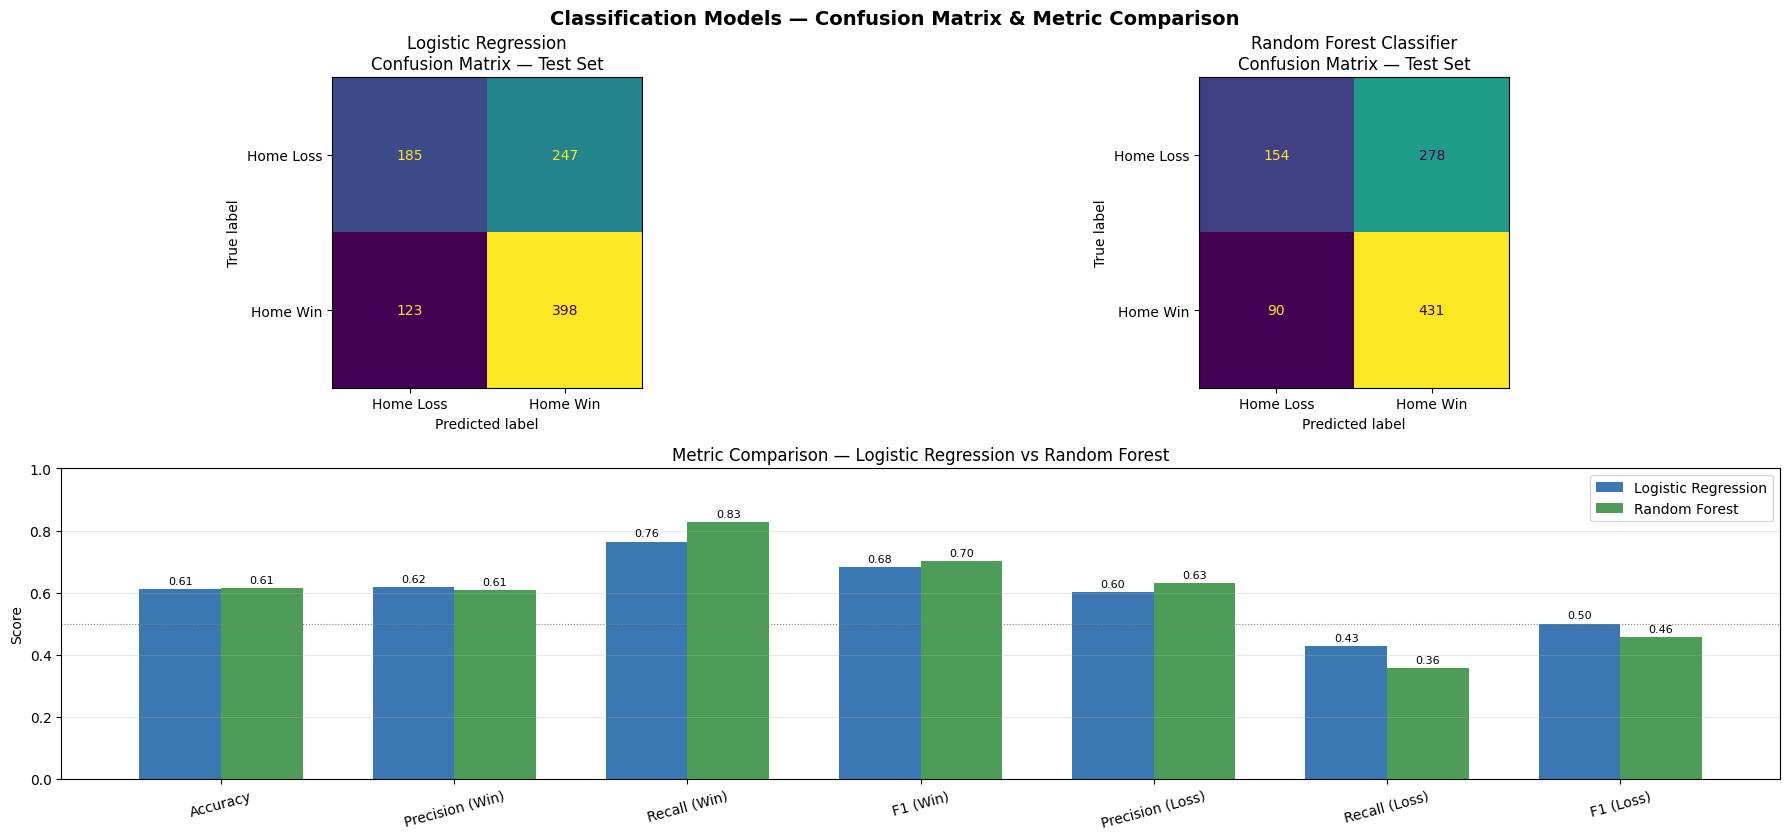

In [21]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Classification Models — Confusion Matrix & Metric Comparison", fontsize=14, fontweight="bold")

cm_lr = confusion_matrix(y_clf_test, lr_tst_pred)
cm_rf = confusion_matrix(y_clf_test, rf_clf_tst_pred)

ax1 = fig.add_subplot(3, 2, 1)
ax2 = fig.add_subplot(3, 2, 2)
ConfusionMatrixDisplay(cm_lr, display_labels=["Home Loss","Home Win"]).plot(ax=ax1, colorbar=False)
ax1.set_title("Logistic Regression\nConfusion Matrix — Test Set")
ConfusionMatrixDisplay(cm_rf, display_labels=["Home Loss","Home Win"]).plot(ax=ax2, colorbar=False)
ax2.set_title("Random Forest Classifier\nConfusion Matrix — Test Set")

def get_metrics(cm):
    tn, fp, fn, tp = cm.ravel()
    acc   = (tp+tn)/(tp+tn+fp+fn)
    prec  = tp/(tp+fp) if (tp+fp)>0 else 0
    rec   = tp/(tp+fn) if (tp+fn)>0 else 0
    f1    = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    pl    = tn/(tn+fn) if (tn+fn)>0 else 0
    rl    = tn/(tn+fp) if (tn+fp)>0 else 0
    f1l   = 2*pl*rl/(pl+rl) if (pl+rl)>0 else 0
    return {"Accuracy":round(acc,3),"Precision (Win)":round(prec,3),"Recall (Win)":round(rec,3),
            "F1 (Win)":round(f1,3),"Precision (Loss)":round(pl,3),"Recall (Loss)":round(rl,3),"F1 (Loss)":round(f1l,3)}

mlr = get_metrics(cm_lr)
mrf = get_metrics(cm_rf)
names = list(mlr.keys())
x = np.arange(len(names))
w = 0.35

ax3 = fig.add_subplot(3, 1, 2)
b1 = ax3.bar(x-w/2, list(mlr.values()), w, label="Logistic Regression", color="#185FA5", alpha=0.85)
b2 = ax3.bar(x+w/2, list(mrf.values()), w, label="Random Forest",       color="#2E8B3A", alpha=0.85)
for bar in list(b1)+list(b2):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
ax3.set_xticks(x); ax3.set_xticklabels(names, rotation=15)
ax3.set_ylim(0,1.0); ax3.set_ylabel("Score")
ax3.set_title("Metric Comparison — Logistic Regression vs Random Forest")
ax3.legend(); ax3.axhline(0.5, color="gray", linestyle=":", lw=0.8); ax3.grid(True, alpha=0.3, axis="y")


plt.tight_layout()
plt.savefig("classification_metrics_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

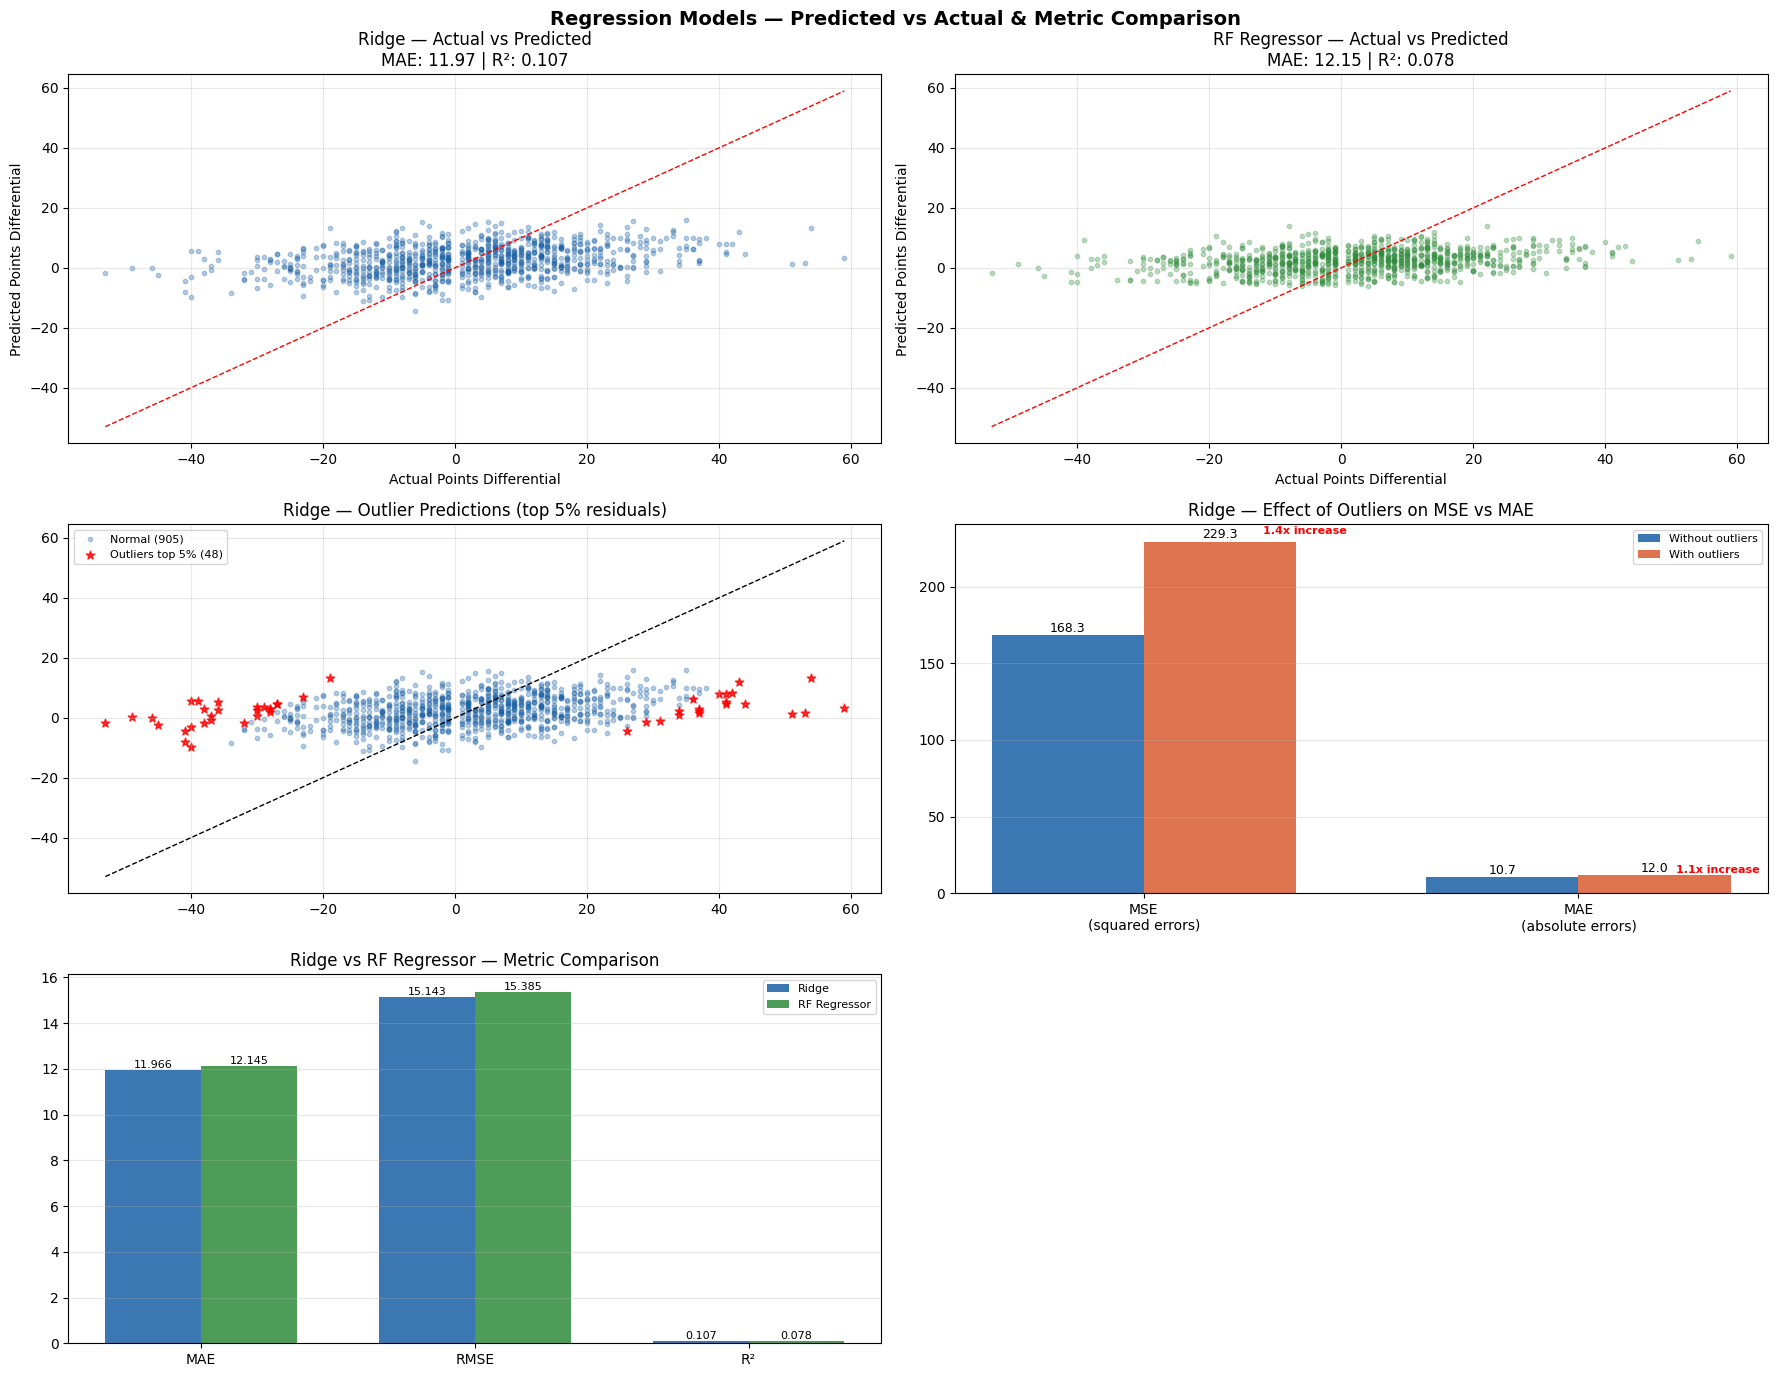

In [10]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Regression Models — Predicted vs Actual & Metric Comparison", fontsize=14, fontweight="bold")

ax1 = fig.add_subplot(3, 2, 1)
ax1.scatter(y_reg_test, ridge_tst_pred, alpha=0.3, color="#185FA5", s=10)
ax1.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], "r--", lw=1)
ax1.set_xlabel("Actual Points Differential"); ax1.set_ylabel("Predicted Points Differential")
ax1.set_title(f"Ridge — Actual vs Predicted\nMAE: {round(mean_absolute_error(y_reg_test,ridge_tst_pred),2)} | R²: {round(r2_score(y_reg_test,ridge_tst_pred),3)}")
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(3, 2, 2)
ax2.scatter(y_reg_test, rf_reg_tst_pred, alpha=0.3, color="#2E8B3A", s=10)
ax2.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], "r--", lw=1)
ax2.set_xlabel("Actual Points Differential"); ax2.set_ylabel("Predicted Points Differential")
ax2.set_title(f"RF Regressor — Actual vs Predicted\nMAE: {round(mean_absolute_error(y_reg_test,rf_reg_tst_pred),2)} | R²: {round(r2_score(y_reg_test,rf_reg_tst_pred),3)}")
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(3, 2, 3)
ridge_residuals = (y_reg_test - ridge_tst_pred).values
threshold  = np.percentile(np.abs(ridge_residuals), 95)
is_outlier = np.abs(ridge_residuals) >= threshold
ax3.scatter(y_reg_test[~is_outlier], ridge_tst_pred[~is_outlier], alpha=0.3, color="#185FA5", s=10, label=f"Normal ({(~is_outlier).sum()})")
ax3.scatter(y_reg_test[is_outlier],  ridge_tst_pred[is_outlier],  alpha=0.8, color="red", s=40, marker="*", label=f"Outliers top 5% ({is_outlier.sum()})")
ax3.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], "k--", lw=1)
ax3.set_title("Ridge — Outlier Predictions (top 5% residuals)"); ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(3, 2, 4)
mae_clean = mean_absolute_error(y_reg_test[~is_outlier], ridge_tst_pred[~is_outlier])
mse_clean = mean_squared_error(y_reg_test[~is_outlier],  ridge_tst_pred[~is_outlier])
mae_all   = mean_absolute_error(y_reg_test, ridge_tst_pred)
mse_all   = mean_squared_error(y_reg_test,  ridge_tst_pred)
xb = np.arange(2); wb = 0.35
b1 = ax4.bar(xb-wb/2, [mse_clean, mae_clean], wb, label="Without outliers", color="#185FA5", alpha=0.85)
b2 = ax4.bar(xb+wb/2, [mse_all,   mae_all],   wb, label="With outliers",    color="#D85A30", alpha=0.85)
for bar in list(b1)+list(b2):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)
ax4.annotate(f"{round(mse_all/mse_clean,1)}x increase", xy=(0+wb/2,mse_all), xytext=(0+wb/2+0.1,mse_all+5), fontsize=8, color="red", fontweight="bold")
ax4.annotate(f"{round(mae_all/mae_clean,1)}x increase", xy=(1+wb/2,mae_all), xytext=(1+wb/2+0.05,mae_all+1), fontsize=8, color="red", fontweight="bold")
ax4.set_xticks(xb); ax4.set_xticklabels(["MSE\n(squared errors)","MAE\n(absolute errors)"])
ax4.set_title("Ridge — Effect of Outliers on MSE vs MAE"); ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3, axis="y")

ax5 = fig.add_subplot(3, 2, 5)
metrics    = ["MAE","RMSE","R²"]
rv = [round(mean_absolute_error(y_reg_test,ridge_tst_pred),3), round(np.sqrt(mean_squared_error(y_reg_test,ridge_tst_pred)),3), round(r2_score(y_reg_test,ridge_tst_pred),3)]
fv = [round(mean_absolute_error(y_reg_test,rf_reg_tst_pred),3), round(np.sqrt(mean_squared_error(y_reg_test,rf_reg_tst_pred)),3), round(r2_score(y_reg_test,rf_reg_tst_pred),3)]
xm = np.arange(3); wm = 0.35
b1 = ax5.bar(xm-wm/2, rv, wm, label="Ridge",        color="#185FA5", alpha=0.85)
b2 = ax5.bar(xm+wm/2, fv, wm, label="RF Regressor", color="#2E8B3A", alpha=0.85)
for bar in list(b1)+list(b2):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
ax5.set_xticks(xm); ax5.set_xticklabels(metrics)
ax5.set_title("Ridge vs RF Regressor — Metric Comparison"); ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("regression_metrics_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

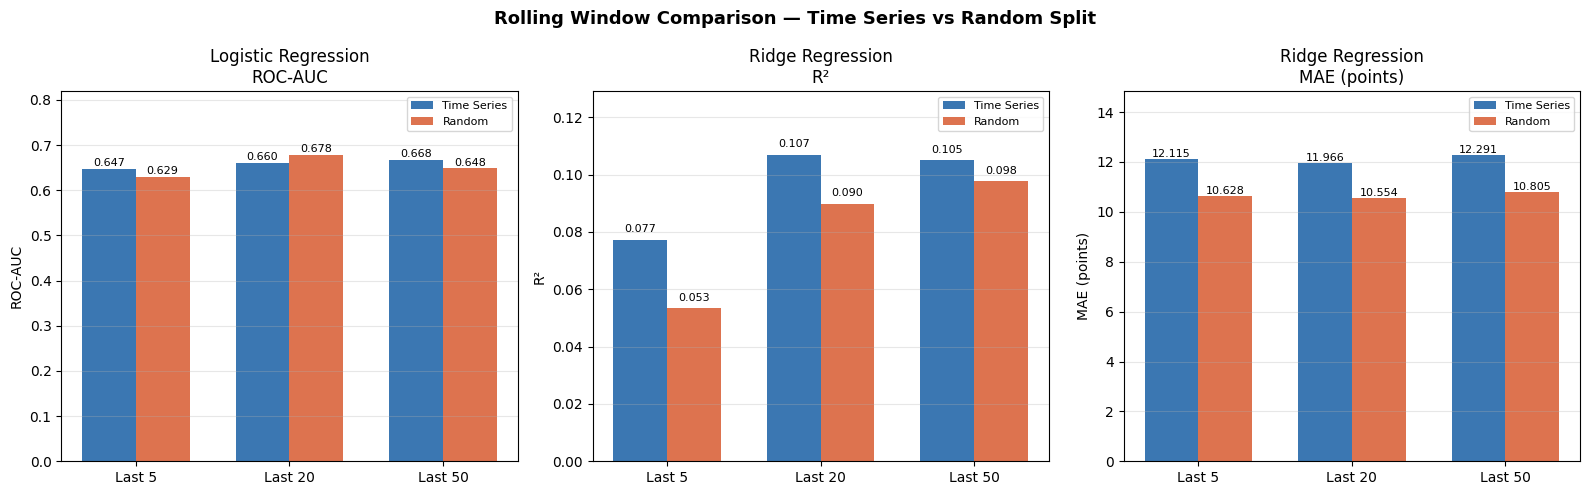

In [15]:
df5  = pd.read_csv("nba_long_dataset.csv")
df20 = pd.read_csv("nba_long_dataset2.csv")
df50 = pd.read_csv("nba_long_dataset3.csv")

results_ts = []; results_rnd = []

for name, df_temp in [("Last 5", df5), ("Last 20", df20), ("Last 50", df50)]:
    df_temp = df_temp.copy()
    df_temp["GAME_DATE"]       = pd.to_datetime(df_temp["GAME_DATE"])
    df_temp                    = df_temp.sort_values("GAME_DATE").reset_index(drop=True)
    df_temp["ACTUAL_PTS_DIFF"] = df_temp["PTS_HOME"] - df_temp["PTS_AWAY"]
    feats   = ["PTS_DIFF","REB_DIFF","AST_DIFF","TOV_DIFF","EFG_DIFF","TRAVEL_DIST"]
    df_temp = df_temp.dropna(subset=feats+["HOME_WIN","ACTUAL_PTS_DIFF"])
    X = df_temp[feats]; yc = df_temp["HOME_WIN"].astype(int); yr = df_temp["ACTUAL_PTS_DIFF"]
    n = len(df_temp)

    # Time series
    Xtr, Xte = X.iloc[:int(n*0.70)], X.iloc[int(n*0.90):]
    yctr, ycte = yc.iloc[:int(n*0.70)], yc.iloc[int(n*0.90):]
    yrtr, yrte = yr.iloc[:int(n*0.70)], yr.iloc[int(n*0.90):]
    sc = StandardScaler(); Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)
    lr_t = LogisticRegression(max_iter=100,random_state=42).fit(Xtr_s,yctr)
    ri_t = Ridge(alpha=1.0).fit(Xtr_s,yrtr)
    results_ts.append({"window":name, "LR_AUC":round(roc_auc_score(ycte,lr_t.predict_proba(Xte_s)[:,1]),4),
                       "RIDGE_R2":round(r2_score(yrte,ri_t.predict(Xte_s)),4),
                       "RIDGE_MAE":round(mean_absolute_error(yrte,ri_t.predict(Xte_s)),4)})

    # Random
    Xtr_r,Xte_r,yctr_r,ycte_r = train_test_split(X,yc,test_size=0.10,random_state=42)
    _,_,yrtr_r,yrte_r          = train_test_split(X,yr,test_size=0.10,random_state=42)
    sc2 = StandardScaler(); Xtr_r_s,Xte_r_s = sc2.fit_transform(Xtr_r),sc2.transform(Xte_r)
    lr_r = LogisticRegression(max_iter=100,random_state=42).fit(Xtr_r_s,yctr_r)
    ri_r = Ridge(alpha=1.0).fit(Xtr_r_s,yrtr_r)
    results_rnd.append({"window":name, "LR_AUC":round(roc_auc_score(ycte_r,lr_r.predict_proba(Xte_r_s)[:,1]),4),
                        "RIDGE_R2":round(r2_score(yrte_r,ri_r.predict(Xte_r_s)),4),
                        "RIDGE_MAE":round(mean_absolute_error(yrte_r,ri_r.predict(Xte_r_s)),4)})

windows = [r["window"] for r in results_ts]
x = np.arange(len(windows)); w = 0.35
fig, axes = plt.subplots(1,3,figsize=(16,5))
fig.suptitle("Rolling Window Comparison — Time Series vs Random Split", fontsize=13, fontweight="bold")
for ax, key, ylabel, title in [
    (axes[0],"LR_AUC",   "ROC-AUC",    "Logistic Regression\nROC-AUC"),
    (axes[1],"RIDGE_R2", "R²",         "Ridge Regression\nR²"),
    (axes[2],"RIDGE_MAE","MAE (points)","Ridge Regression\nMAE (points)"),
]:
    ts_v  = [r[key] for r in results_ts]
    rnd_v = [r[key] for r in results_rnd]
    b1 = ax.bar(x-w/2, ts_v,  w, label="Time Series", color="#185FA5", alpha=0.85)
    b2 = ax.bar(x+w/2, rnd_v, w, label="Random",      color="#D85A30", alpha=0.85)
    for bar in list(b1)+list(b2):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(windows); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")
for ax in axes:
    ax.set_ylim(bottom=ax.get_ylim()[0], top=ax.get_ylim()[1] * 1.15)
plt.tight_layout()
plt.savefig("window_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
test_years = [2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025]
results_sw = []
tscv3 = TimeSeriesSplit(n_splits=3)

for test_year in test_years:
    tr = df[(df["GAME_DATE"].dt.year >= test_year-2) & (df["GAME_DATE"].dt.year < test_year)]
    te = df[df["GAME_DATE"].dt.year == test_year]
    if len(tr) < 100 or len(te) == 0: continue
    Xtr,Xte = tr[reg_features],te[reg_features]
    yctr,ycte = tr["HOME_WIN"].astype(int),te["HOME_WIN"].astype(int)
    yrtr,yrte = tr["ACTUAL_PTS_DIFF"],te["ACTUAL_PTS_DIFF"]
    sc = StandardScaler(); Xtr_s,Xte_s = sc.fit_transform(Xtr),sc.transform(Xte)

    lr_sw = LogisticRegression(max_iter=100,random_state=42)
    lr_cv = cross_val_score(lr_sw,Xtr_s,yctr,cv=tscv3,scoring="roc_auc").mean()
    lr_sw.fit(Xtr_s,yctr); lr_auc = round(roc_auc_score(ycte,lr_sw.predict_proba(Xte_s)[:,1]),4)

    rf_sw = RandomForestClassifier(n_estimators=100,max_depth=3,min_samples_leaf=10,random_state=42)
    rf_cv = cross_val_score(rf_sw,Xtr_s,yctr,cv=tscv3,scoring="roc_auc").mean()
    rf_sw.fit(Xtr_s,yctr); rf_auc = round(roc_auc_score(ycte,rf_sw.predict_proba(Xte_s)[:,1]),4)

    ri_sw = Ridge(alpha=1.0)
    ri_cv = cross_val_score(ri_sw,Xtr_s,yrtr,cv=tscv3,scoring="r2").mean()
    ri_sw.fit(Xtr_s,yrtr); ri_r2=round(r2_score(yrte,ri_sw.predict(Xte_s)),4); ri_mae=round(mean_absolute_error(yrte,ri_sw.predict(Xte_s)),4)

    rfr_sw = RandomForestRegressor(n_estimators=100,max_depth=3,min_samples_leaf=10,random_state=42)
    rfr_cv = cross_val_score(rfr_sw,Xtr_s,yrtr,cv=tscv3,scoring="r2").mean()
    rfr_sw.fit(Xtr_s,yrtr); rfr_r2=round(r2_score(yrte,rfr_sw.predict(Xte_s)),4); rfr_mae=round(mean_absolute_error(yrte,rfr_sw.predict(Xte_s)),4)

    results_sw.append({"test_year":test_year,"train_size":len(tr),
        "LR_CV_AUC":round(lr_cv,4),"LR_TST_AUC":lr_auc,
        "RF_CV_AUC":round(rf_cv,4),"RF_TST_AUC":rf_auc,
        "RID_CV_R2":round(ri_cv,4),"RID_TST_R2":ri_r2,"RID_TST_MAE":ri_mae,
        "RFR_CV_R2":round(rfr_cv,4),"RFR_TST_R2":rfr_r2,"RFR_TST_MAE":rfr_mae})
    print(f"{test_year} | LR: {lr_auc} | RF: {rf_auc} | Ridge R²: {ri_r2} | RFReg R²: {rfr_r2}")

results_df = pd.DataFrame(results_sw)
print("\n", results_df.to_string(index=False))

2016 | LR: 0.6804 | RF: 0.6543 | Ridge R²: 0.1181 | RFReg R²: 0.0874
2017 | LR: 0.611 | RF: 0.6044 | Ridge R²: 0.037 | RFReg R²: 0.0412
2018 | LR: 0.6289 | RF: 0.6242 | Ridge R²: 0.0673 | RFReg R²: 0.0476
2019 | LR: 0.6639 | RF: 0.6425 | Ridge R²: 0.1136 | RFReg R²: 0.0788
2020 | LR: 0.6347 | RF: 0.6163 | Ridge R²: 0.0782 | RFReg R²: 0.0688
2021 | LR: 0.6595 | RF: 0.6478 | Ridge R²: 0.0859 | RFReg R²: 0.0637
2022 | LR: 0.6409 | RF: 0.6341 | Ridge R²: 0.0192 | RFReg R²: -0.0215
2023 | LR: 0.6372 | RF: 0.6093 | Ridge R²: 0.0797 | RFReg R²: 0.0564
2024 | LR: 0.6568 | RF: 0.6535 | Ridge R²: 0.1207 | RFReg R²: 0.1003
2025 | LR: 0.6842 | RF: 0.6867 | Ridge R²: 0.1313 | RFReg R²: 0.1116

  test_year  train_size  LR_CV_AUC  LR_TST_AUC  RF_CV_AUC  RF_TST_AUC  RID_CV_R2  RID_TST_R2  RID_TST_MAE  RFR_CV_R2  RFR_TST_R2  RFR_TST_MAE
      2016         180     0.6130      0.6804     0.6236      0.6543    -0.0278      0.1181      10.1381    -0.0491      0.0874      10.2865
      2017        1427     

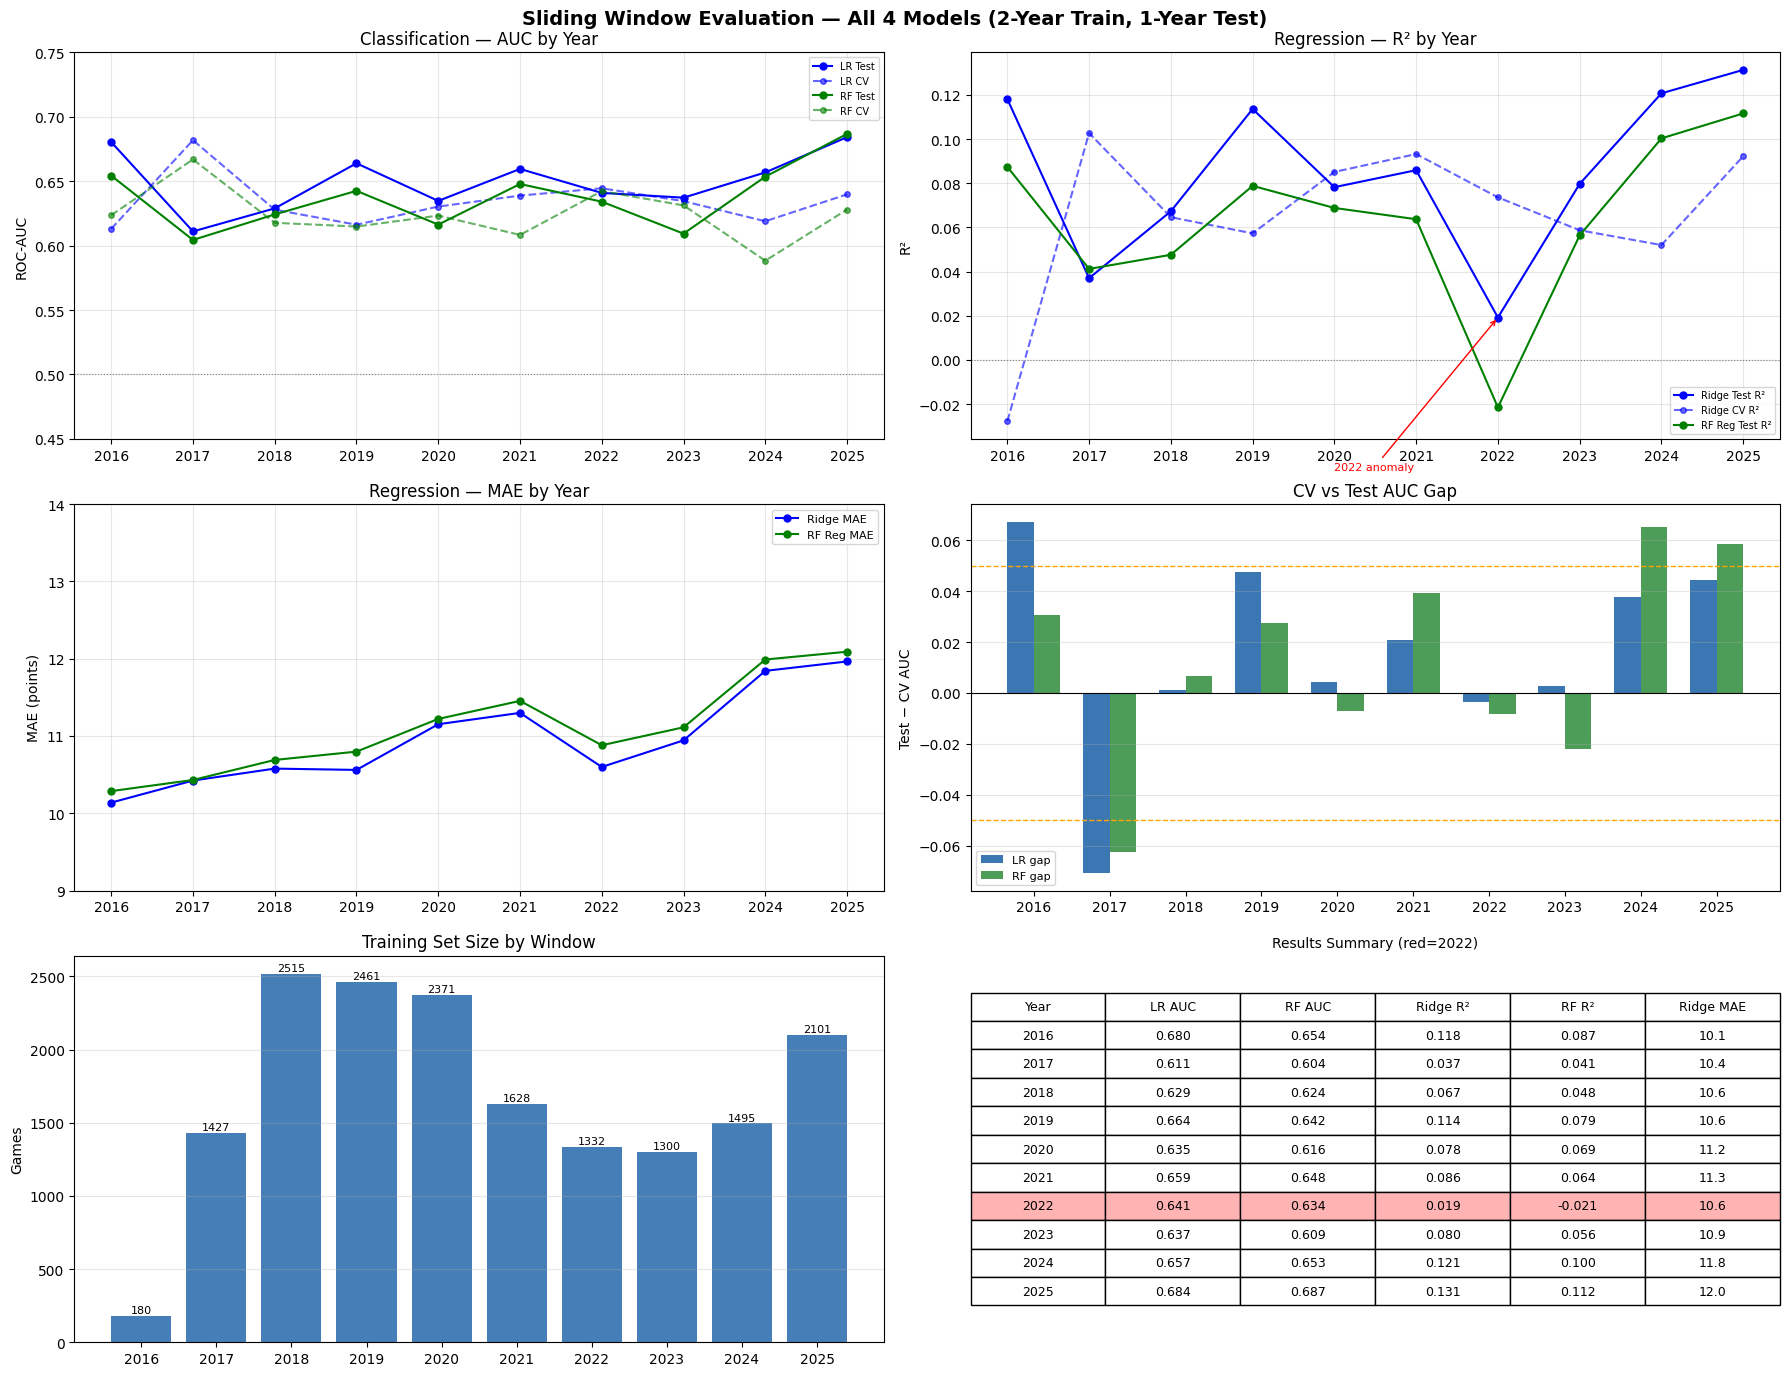

In [16]:
years = results_df["test_year"].values
x = np.arange(len(years)); w = 0.35

fig = plt.figure(figsize=(18,14))
fig.suptitle("Sliding Window Evaluation — All 4 Models (2-Year Train, 1-Year Test)", fontsize=14, fontweight="bold")

ax1 = fig.add_subplot(3,2,1)
ax1.plot(years,results_df["LR_TST_AUC"],"b-o",label="LR Test",markersize=5)
ax1.plot(years,results_df["LR_CV_AUC"],"b--o",label="LR CV",markersize=4,alpha=0.6)
ax1.plot(years,results_df["RF_TST_AUC"],"g-o",label="RF Test",markersize=5)
ax1.plot(years,results_df["RF_CV_AUC"],"g--o",label="RF CV",markersize=4,alpha=0.6)
ax1.axhline(0.5,color="gray",linestyle=":",lw=0.8)
ax1.set_title("Classification — AUC by Year"); ax1.set_ylabel("ROC-AUC"); ax1.set_ylim(0.45,0.75)
ax1.set_xticks(years); ax1.legend(fontsize=7); ax1.grid(True,alpha=0.3)

ax2 = fig.add_subplot(3,2,2)
ax2.plot(years,results_df["RID_TST_R2"],"b-o",label="Ridge Test R²",markersize=5)
ax2.plot(years,results_df["RID_CV_R2"],"b--o",label="Ridge CV R²",markersize=4,alpha=0.6)
ax2.plot(years,results_df["RFR_TST_R2"],"g-o",label="RF Reg Test R²",markersize=5)
ax2.axhline(0,color="gray",linestyle=":",lw=0.8)
ax2.annotate("2022 anomaly",
             xy=(2022,results_df[results_df["test_year"]==2022]["RID_TST_R2"].values[0]),
             xytext=(2020,-0.05),arrowprops=dict(arrowstyle="->",color="red"),fontsize=8,color="red")
ax2.set_title("Regression — R² by Year"); ax2.set_ylabel("R²")
ax2.set_xticks(years); ax2.legend(fontsize=7); ax2.grid(True,alpha=0.3)

ax3 = fig.add_subplot(3,2,3)
ax3.plot(years,results_df["RID_TST_MAE"],"b-o",label="Ridge MAE",markersize=5)
ax3.plot(years,results_df["RFR_TST_MAE"],"g-o",label="RF Reg MAE",markersize=5)
ax3.set_title("Regression — MAE by Year"); ax3.set_ylabel("MAE (points)"); ax3.set_ylim(9,14)
ax3.set_xticks(years); ax3.legend(fontsize=8); ax3.grid(True,alpha=0.3)

ax4 = fig.add_subplot(3,2,4)
lr_gap = results_df["LR_TST_AUC"]-results_df["LR_CV_AUC"]
rf_gap = results_df["RF_TST_AUC"]-results_df["RF_CV_AUC"]
ax4.bar(x-w/2,lr_gap,w,label="LR gap",color="#185FA5",alpha=0.85)
ax4.bar(x+w/2,rf_gap,w,label="RF gap",color="#2E8B3A",alpha=0.85)
ax4.axhline(0,color="black",lw=0.8); ax4.axhline(0.05,color="orange",linestyle="--",lw=1)
ax4.axhline(-0.05,color="orange",linestyle="--",lw=1)
ax4.set_title("CV vs Test AUC Gap"); ax4.set_ylabel("Test − CV AUC")
ax4.set_xticks(x); ax4.set_xticklabels(years); ax4.legend(fontsize=8); ax4.grid(True,alpha=0.3,axis="y")

ax5 = fig.add_subplot(3,2,5)
ax5.bar(years,results_df["train_size"],color="#185FA5",alpha=0.8)
ax5.set_title("Training Set Size by Window"); ax5.set_ylabel("Games")
ax5.set_xticks(years)
for yr,sz in zip(years,results_df["train_size"]):
    ax5.text(yr,sz+20,str(sz),ha="center",fontsize=8)
ax5.grid(True,alpha=0.3,axis="y")

ax6 = fig.add_subplot(3,2,6)
ax6.axis("off")
table_data = [[int(r["test_year"]),f"{r['LR_TST_AUC']:.3f}",f"{r['RF_TST_AUC']:.3f}",
               f"{r['RID_TST_R2']:.3f}",f"{r['RFR_TST_R2']:.3f}",f"{r['RID_TST_MAE']:.1f}"]
              for _,r in results_df.iterrows()]
tbl = ax6.table(cellText=table_data,colLabels=["Year","LR AUC","RF AUC","Ridge R²","RF R²","Ridge MAE"],
                cellLoc="center",loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1,1.4)
idx_2022 = results_df[results_df['test_year']==2022].index[0]
for j in range(6): 
    tbl[idx_2022 + 1, j].set_facecolor("#FFB3B3")
ax6.set_title("Results Summary (red=2022)", fontsize=10)

plt.tight_layout()
plt.savefig("sliding_window_results.png",dpi=150,bbox_inches="tight")
plt.show()

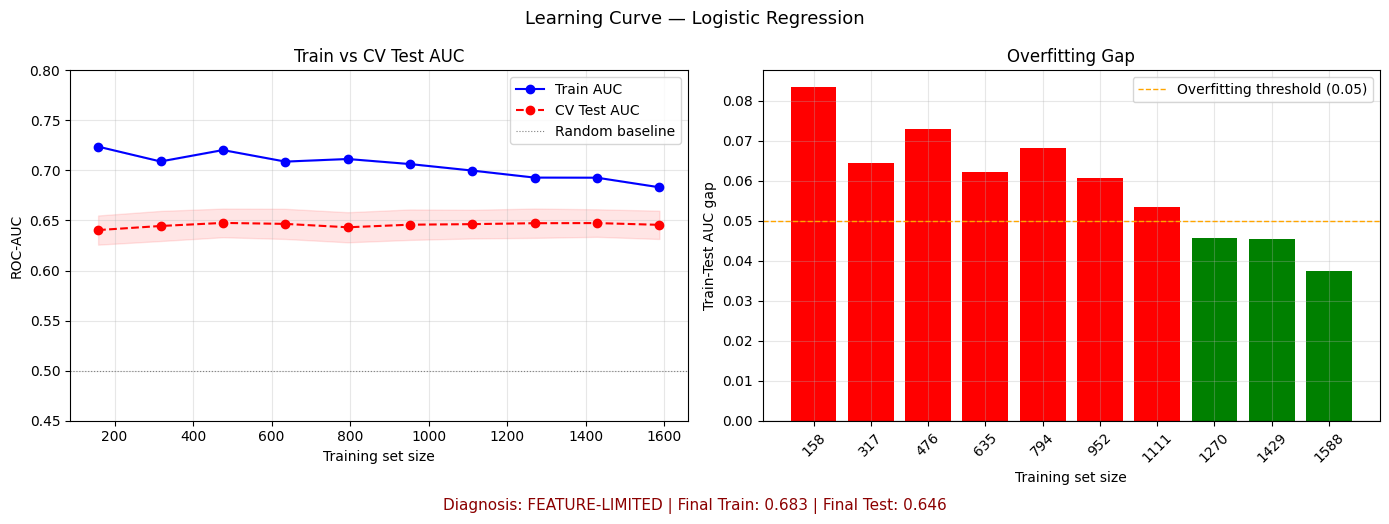

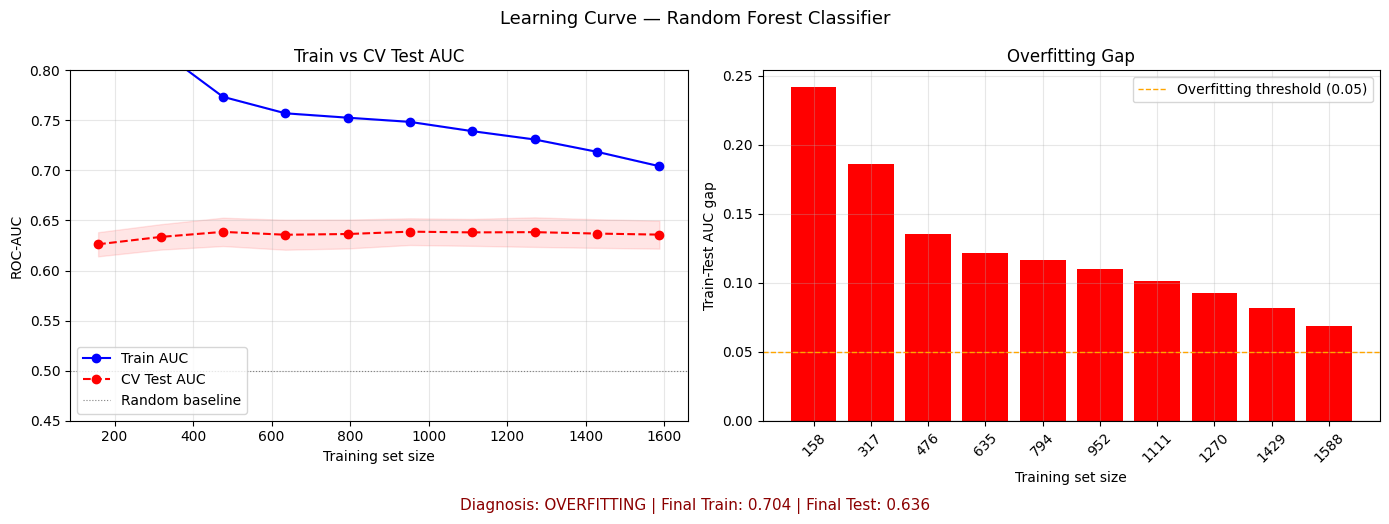

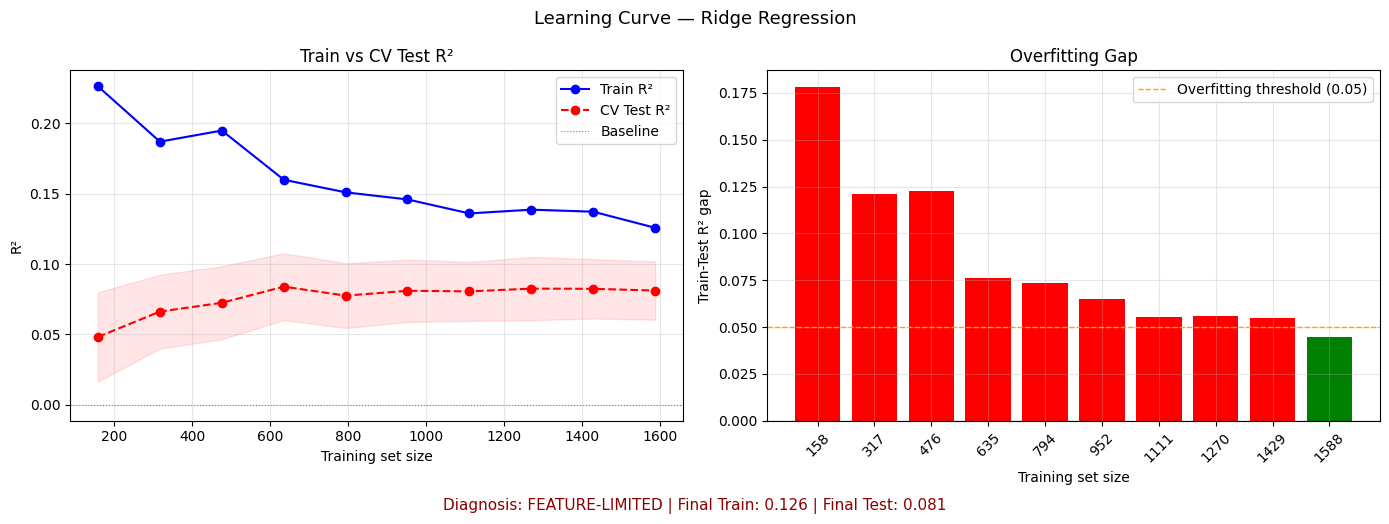

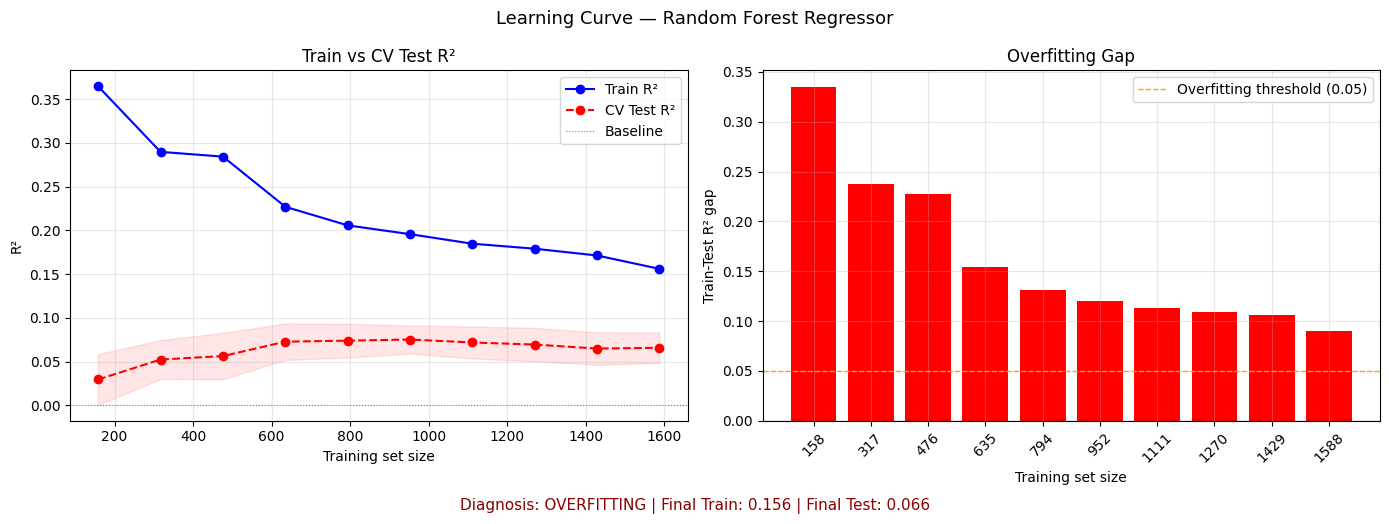

In [14]:
X_full     = df[reg_features]
y_clf_full = df["HOME_WIN"].astype(int)
y_reg_full = df["ACTUAL_PTS_DIFF"]
tscv = TimeSeriesSplit(n_splits=5)

def plot_lc_clf(model, X, y, title):
    pipe = Pipeline([("scaler",StandardScaler()),("model",model)])
    ts,tr,te = learning_curve(pipe,X,y,cv=tscv,scoring="roc_auc",train_sizes=np.linspace(0.1,1.0,10),n_jobs=-1)
    tm,ts2 = tr.mean(axis=1),tr.std(axis=1)
    em,es  = te.mean(axis=1),te.std(axis=1)
    gap    = tm-em
    fig,axes = plt.subplots(1,2,figsize=(14,5))
    fig.suptitle(f"Learning Curve — {title}",fontsize=13)
    axes[0].plot(ts,tm,"o-",color="blue",label="Train AUC")
    axes[0].plot(ts,em,"o",color="red",linestyle="--",label="CV Test AUC")
    axes[0].fill_between(ts,tm-ts2,tm+ts2,alpha=0.1,color="blue")
    axes[0].fill_between(ts,em-es,em+es,alpha=0.1,color="red")
    axes[0].axhline(0.5,color="gray",linestyle=":",lw=0.8,label="Random baseline")
    axes[0].set_xlabel("Training set size"); axes[0].set_ylabel("ROC-AUC"); axes[0].set_ylim(0.45,0.80)
    axes[0].legend(); axes[0].grid(True,alpha=0.3); axes[0].set_title("Train vs CV Test AUC")
    colors=["red" if g>0.05 else "green" for g in gap]
    axes[1].bar(range(len(gap)),gap,color=colors)
    axes[1].axhline(0.05,color="orange",linestyle="--",lw=1,label="Overfitting threshold (0.05)")
    axes[1].axhline(0,color="black",lw=0.8)
    axes[1].set_xticks(range(len(gap))); axes[1].set_xticklabels([f"{int(s)}" for s in ts],rotation=45)
    axes[1].set_xlabel("Training set size"); axes[1].set_ylabel("Train-Test AUC gap")
    axes[1].set_title("Overfitting Gap"); axes[1].legend(); axes[1].grid(True,alpha=0.3)
    diag = "OVERFITTING" if gap[-1]>0.05 else ("UNDERFITTING" if tm[-1]<0.60 and em[-1]<0.60 else "FEATURE-LIMITED")
    fig.text(0.5,-0.02,f"Diagnosis: {diag} | Final Train: {tm[-1]:.3f} | Final Test: {em[-1]:.3f}",ha="center",fontsize=11,color="darkred")
    plt.tight_layout(); plt.savefig(f"lc_{title.replace(' ','_')}.png",dpi=150,bbox_inches="tight"); plt.show()

def plot_lc_reg(model, X, y, title):
    pipe = Pipeline([("scaler",StandardScaler()),("model",model)])
    ts,tr,te = learning_curve(pipe,X,y,cv=tscv,scoring="r2",train_sizes=np.linspace(0.1,1.0,10),n_jobs=-1)
    tm,ts2 = tr.mean(axis=1),tr.std(axis=1)
    em,es  = te.mean(axis=1),te.std(axis=1)
    gap    = tm-em
    fig,axes = plt.subplots(1,2,figsize=(14,5))
    fig.suptitle(f"Learning Curve — {title}",fontsize=13)
    axes[0].plot(ts,tm,"o-",color="blue",label="Train R²")
    axes[0].plot(ts,em,"o",color="red",linestyle="--",label="CV Test R²")
    axes[0].fill_between(ts,tm-ts2,tm+ts2,alpha=0.1,color="blue")
    axes[0].fill_between(ts,em-es,em+es,alpha=0.1,color="red")
    axes[0].axhline(0,color="gray",linestyle=":",lw=0.8,label="Baseline")
    axes[0].set_xlabel("Training set size"); axes[0].set_ylabel("R²")
    axes[0].legend(); axes[0].grid(True,alpha=0.3); axes[0].set_title("Train vs CV Test R²")
    colors=["red" if g>0.05 else "green" for g in gap]
    axes[1].bar(range(len(gap)),gap,color=colors)
    axes[1].axhline(0.05,color="orange",linestyle="--",lw=1,label="Overfitting threshold (0.05)")
    axes[1].axhline(0,color="black",lw=0.8)
    axes[1].set_xticks(range(len(gap))); axes[1].set_xticklabels([f"{int(s)}" for s in ts],rotation=45)
    axes[1].set_xlabel("Training set size"); axes[1].set_ylabel("Train-Test R² gap")
    axes[1].set_title("Overfitting Gap"); axes[1].legend(); axes[1].grid(True,alpha=0.3)
    diag = "OVERFITTING" if gap[-1]>0.05 else ("UNDERFITTING" if tm[-1]<0.05 and em[-1]<0.05 else "FEATURE-LIMITED")
    fig.text(0.5,-0.02,f"Diagnosis: {diag} | Final Train: {tm[-1]:.3f} | Final Test: {em[-1]:.3f}",ha="center",fontsize=11,color="darkred")
    plt.tight_layout(); plt.savefig(f"lc_{title.replace(' ','_')}.png",dpi=150,bbox_inches="tight"); plt.show()

plot_lc_clf(LogisticRegression(random_state=42), X_full, y_clf_full, "Logistic Regression")
plot_lc_clf(RandomForestClassifier(n_estimators=100,max_depth=3,min_samples_leaf=10,random_state=42), X_full, y_clf_full, "Random Forest Classifier")
plot_lc_reg(Ridge(alpha=1.0), X_full, y_reg_full, "Ridge Regression")
plot_lc_reg(RandomForestRegressor(n_estimators=100,max_depth=3,min_samples_leaf=10,random_state=42), X_full, y_reg_full, "Random Forest Regressor")

In [18]:
for i in range(len(results_df) + 1):
    try:
        print(f"Row {i}:", [tbl[i, j].get_text().get_text() for j in range(6)])
    except:
        print(f"Row {i}: error")


Row 0: ['Year', 'LR AUC', 'RF AUC', 'Ridge R²', 'RF R²', 'Ridge MAE']
Row 1: ['2016', '0.680', '0.654', '0.118', '0.087', '10.1']
Row 2: ['2017', '0.611', '0.604', '0.037', '0.041', '10.4']
Row 3: ['2018', '0.629', '0.624', '0.067', '0.048', '10.6']
Row 4: ['2019', '0.664', '0.642', '0.114', '0.079', '10.6']
Row 5: ['2020', '0.635', '0.616', '0.078', '0.069', '11.2']
Row 6: ['2021', '0.659', '0.648', '0.086', '0.064', '11.3']
Row 7: ['2022', '0.641', '0.634', '0.019', '-0.021', '10.6']
Row 8: ['2023', '0.637', '0.609', '0.080', '0.056', '10.9']
Row 9: ['2024', '0.657', '0.653', '0.121', '0.100', '11.8']
Row 10: ['2025', '0.684', '0.687', '0.131', '0.112', '12.0']


In [20]:
# Clear any cached figures
plt.close('all')

# ... all your ax1-ax5 plot code ...

# Then at the end, explicitly highlight row 7
ax6.axis("off")
table_data = [[int(r["test_year"]),f"{r['LR_TST_AUC']:.3f}",f"{r['RF_TST_AUC']:.3f}",
               f"{r['RID_TST_R2']:.3f}",f"{r['RFR_TST_R2']:.3f}",f"{r['RID_TST_MAE']:.1f}"]
              for _,r in results_df.iterrows()]
tbl = ax6.table(cellText=table_data,colLabels=["Year","LR AUC","RF AUC","Ridge R²","RF R²","Ridge MAE"],
                cellLoc="center",loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1,1.4)

# Highlight 2022 — verified as row 7
for j in range(6): 
    tbl[7, j].set_facecolor("#FFB3B3")

# Verify what got highlighted
print("Highlighted row 7:", [tbl[7,j].get_text().get_text() for j in range(6)])

plt.tight_layout()
plt.savefig("sliding_window_results.png", dpi=150, bbox_inches="tight")
plt.show()

Highlighted row 7: ['2022', '0.641', '0.634', '0.019', '-0.021', '10.6']


<Figure size 640x480 with 0 Axes>